# Generation for iAAFT Surrogates

This notebook uses an example EEG example segment, and it compares univariate and multivariate iAAFT surrogates.



## 1) Load example data and surrogate functions

We load the bundled EEG example and import helper functions from this repository (`iAAFT.py` and `mv_iAAFT.py`).

In [1]:
import pickle
from iAAFT import generate_uv_surrogate
from mv_iAAFT import generate_mv_surrogate
import numpy as np

load_path = 'example_eeg_segment.pkl'
with open(load_path, 'rb') as f:
    saved = pickle.load(f)

eeg_data = saved['eeg_data']
label = saved['label']
combined_cp = saved['combined_cp']

## 3) Define analysis window and univariate surrogate settings

We extract an 8-second window (`5s` to `13s`) and analyze one representative channel (`channel_index=9`).

Three univariate surrogate variants are generated:
- global iAAFT (no changepoints)
- changepoint-constrained iAAFT with small fixed margins (`margin_exact=0.01`)
- changepoint-constrained iAAFT with larger fixed margins (`margin_exact=0.1`)

This side-by-side setup highlights the effect of segmentation and edge preservation on the surrogate dynamics.

In [2]:
fs = 256
start_s, end_s = 5, 13
channel_index = 9

cropped_eeg = eeg_data[:, start_s * fs:end_s * fs]
expanded_array = np.expand_dims(cropped_eeg[channel_index], axis=0)

# Baseline univariate surrogate without changepoints
surrogate_eeg, _ = generate_uv_surrogate(
    expanded_array,
    fs=fs,
    changepoints=[],
    min_distance=256,
    margin_exact=0,
    verbose=False,
)

# Changepoint-constrained variants
cp_list = [0, 1170, 1650, 1800, 2048]
surrogate_eeg_with_cp, _ = generate_uv_surrogate(
    expanded_array,
    fs=fs,
    changepoints=cp_list,
    min_distance=128,
    margin_exact=0.01,
    verbose=False,
)

surrogate_eeg_with_cp_margin01, _ = generate_uv_surrogate(
    expanded_array,
    fs=fs,
    changepoints=cp_list,
    min_distance=128,
    margin_exact=0.1,
    verbose=False,
)


## 4) Plot univariate comparisons

For each condition, we show a time-domain trace and a spectrogram.
- Dashed black lines mark changepoints.
- Red segments indicate fixed margins that are preserved during surrogate generation.

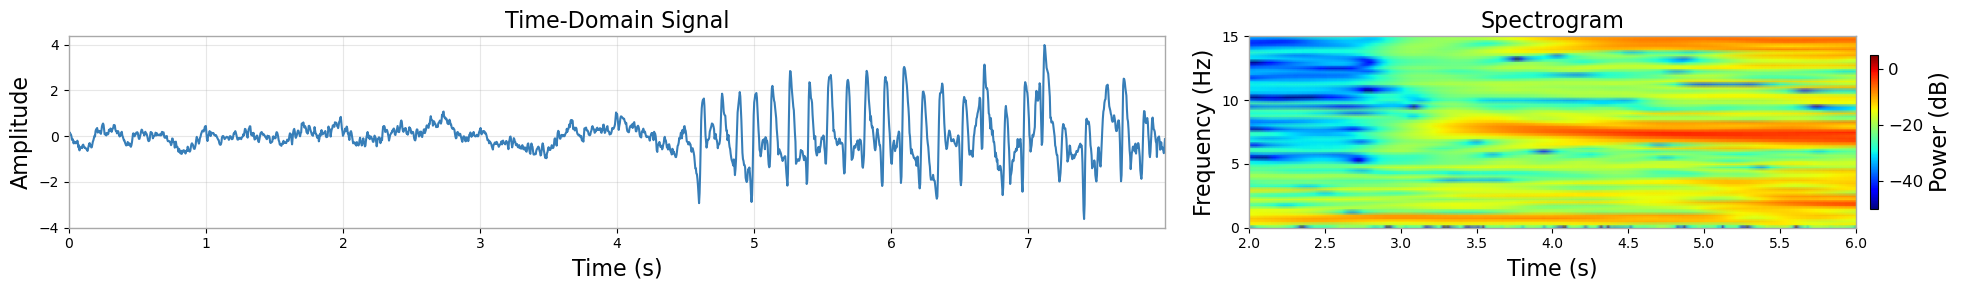

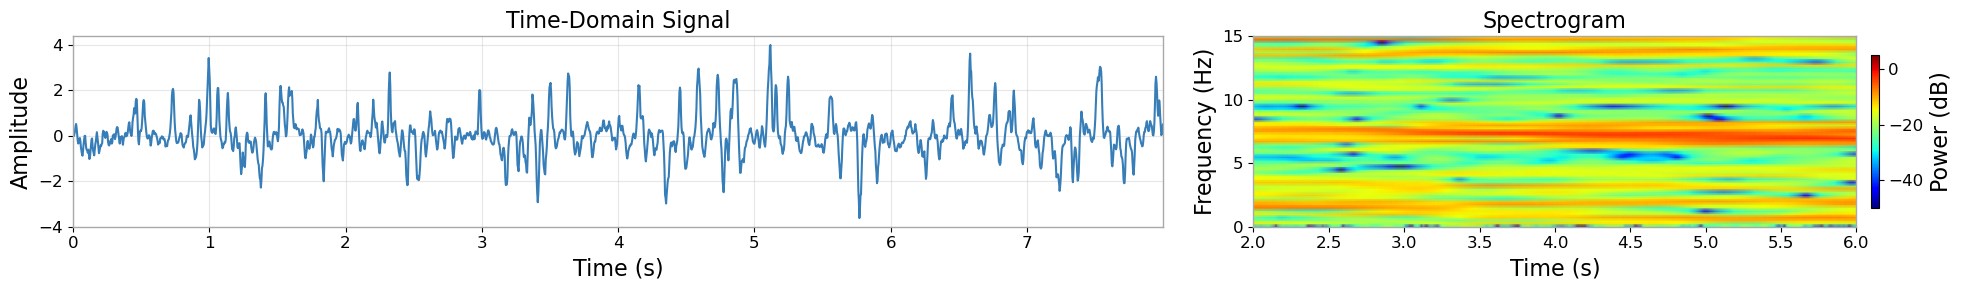

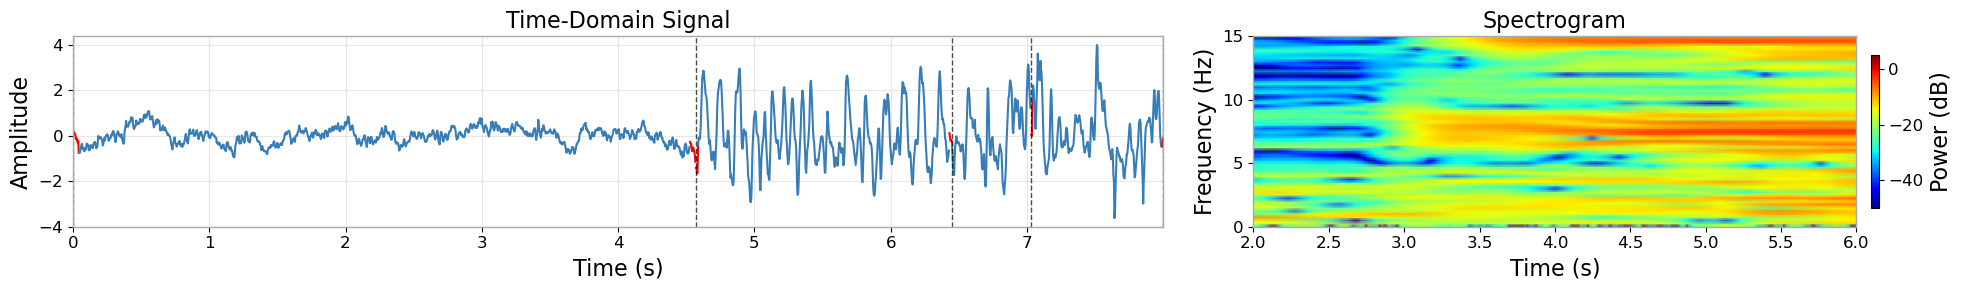

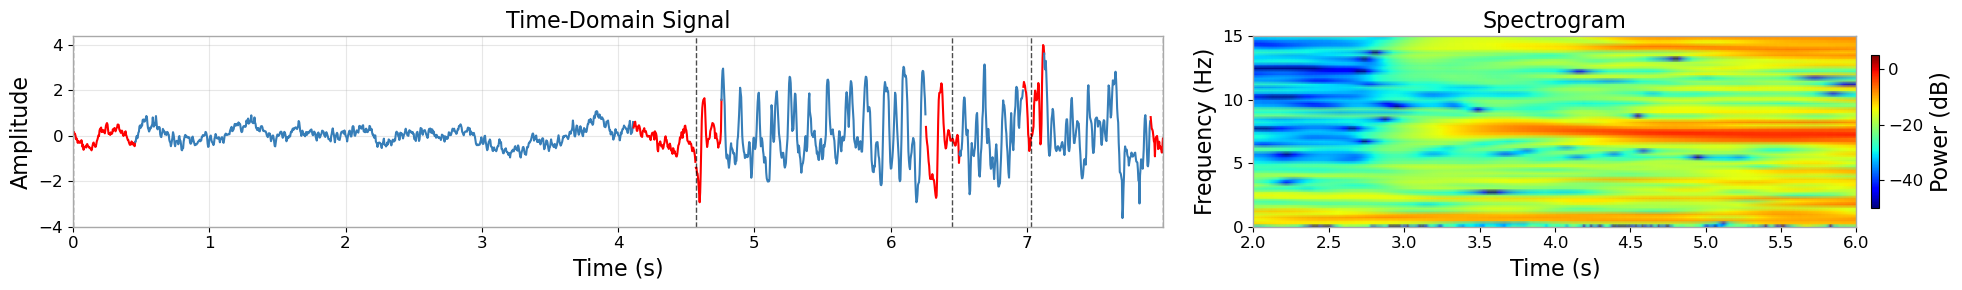

In [3]:
from plots import plot_signal_cp_analysis

plot_signal_cp_analysis(
    expanded_array[0],
    fs=fs,
    cp_list=[],
    fixed_edges=0,
)

plot_signal_cp_analysis(
    surrogate_eeg[0],
    fs=fs,
    cp_list=[],
    fixed_edges=0,
)

plot_signal_cp_analysis(
    surrogate_eeg_with_cp[0],
    fs=fs,
    cp_list=cp_list,
    fixed_edges=0.01,
)

plot_signal_cp_analysis(
    surrogate_eeg_with_cp_margin01[0],
    fs=fs,
    cp_list=cp_list,
    fixed_edges=0.1,
)

## 5) Run multivariate surrogate baseline

We now run the multivariate surrogate pipeline on the same cropped window.
This provides a baseline that preserves cross-channel phase structure while still enforcing per-channel amplitude/spectral constraints.

In [4]:
surrogate_mv, filtered_cp_mv, segment_info_mv = generate_mv_surrogate(
    cropped_eeg,
    fs,
    changepoints=[0, 350, 640, 1000, 1500, len(cropped_eeg[0])],
    min_distance=256,
    margin_exact=0.1,
    fixed_edges_iterations='first',
    reference_channel=0,
    verbose=False,
)

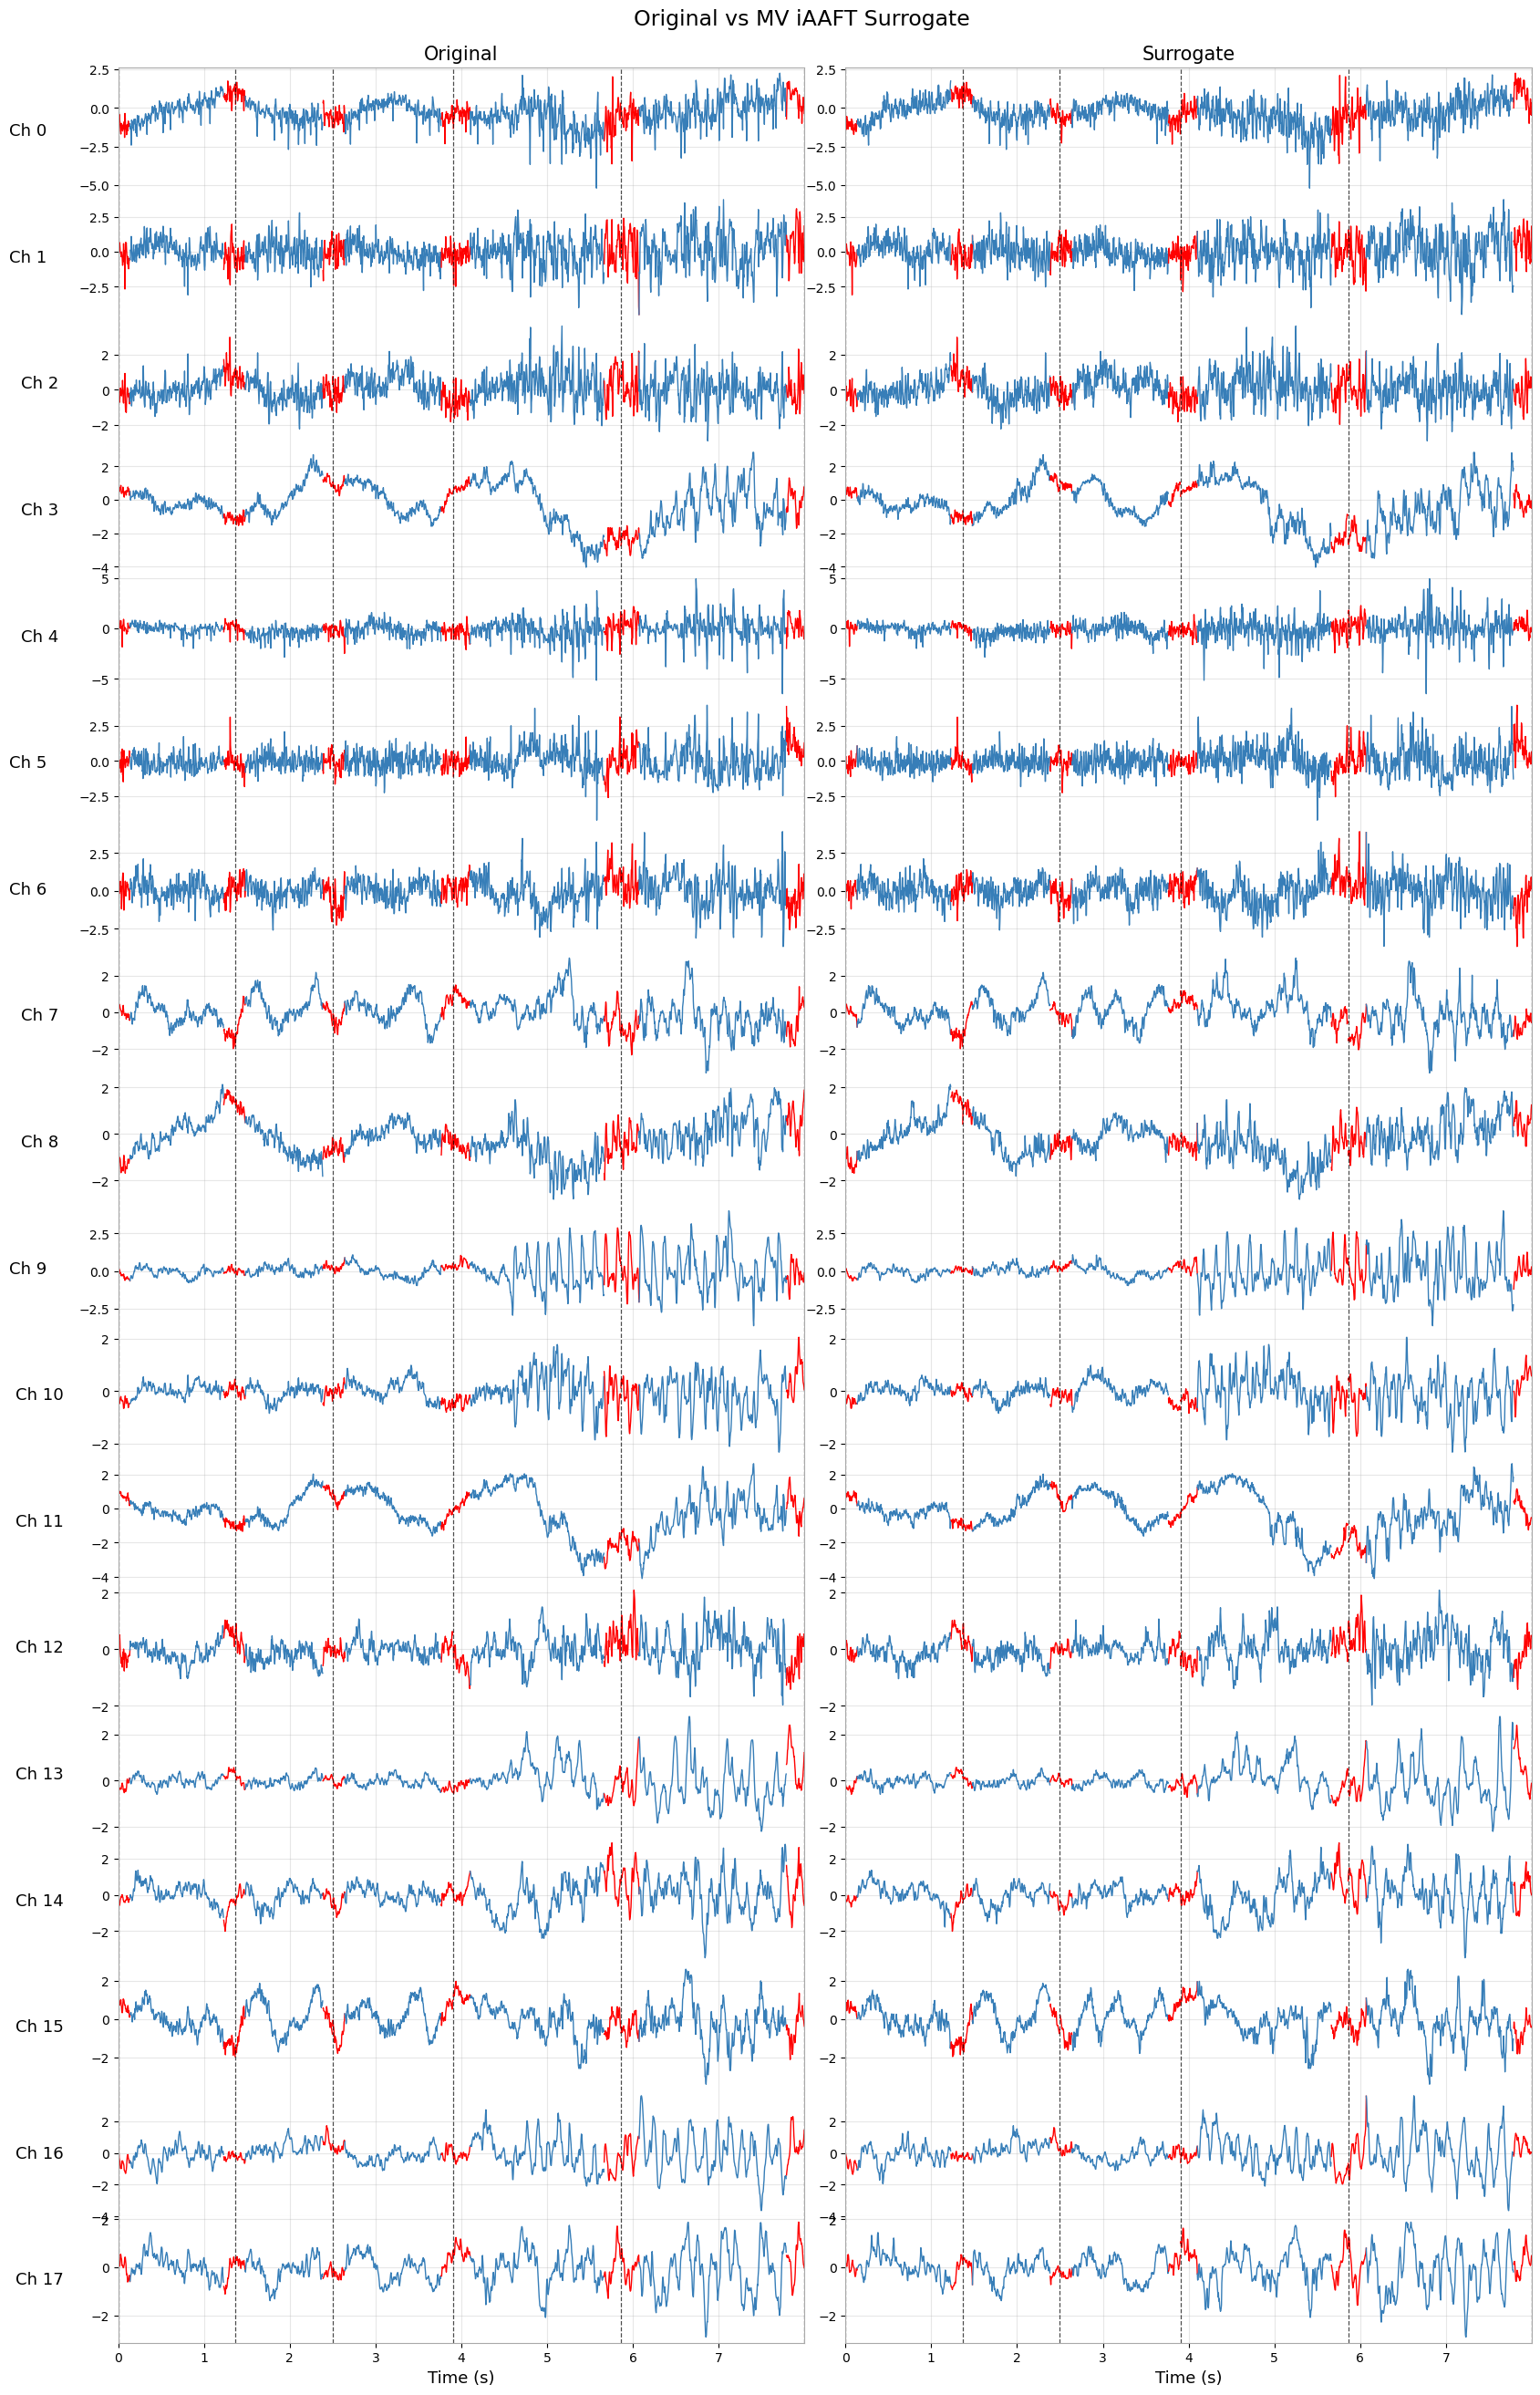

In [5]:
from plots import plot_mv_signal_cp_analysis

plot_mv_signal_cp_analysis(
    cropped_eeg,
    surrogate_mv,
    cp_list=filtered_cp_mv,
    margin_exact=0.1,
    fs=fs,
    title="Original vs MV iAAFT Surrogate",
)